# New Experiments using Dataset v2

- Bayesian hyperparameter optimization via Optuna (TPESampler, 100 trials)
- No imputation, no standardization
- Objective: ROC-AUC (configurable to avg_precision / PR-AUC)
- Metrics: Accuracy, Precision (macro), Recall (macro), F1 (macro), ROC-AUC, PPV, NPV — all with 95% bootstrap CIs
- SHAP beeswarm summary (training data) + PR curve saved alongside model artifacts

In [ ]:
import importlib
import feature_engineering as fe_module
import model as model_module
importlib.reload(fe_module)
importlib.reload(model_module)
from model import train_best_model
import os
import pandas as pd

files = [
    ("datasets/Dataset_v2/pooled_CN.csv", "CN"),
    ("datasets/Dataset_v2/pooled_MCI_AD.csv", "AD"),
]

# params dict: scalar = fixed value, (lo, hi) = int range, (lo, hi, 'log') = log-scale float range
params = {
    'n_estimators':      (100, 500),
    'max_depth':         (3, 7),
    'learning_rate':     (0.005, 0.3, 'log'),
    'subsample':         (0.4, 1.0),
    'colsample_bytree':  (0.4, 1.0),
    'colsample_bylevel': (0.5, 1.0),
    'colsample_bynode':  (0.5, 1.0),
    'min_child_weight':  (1, 10),
    'gamma':             (0.0, 5.0),
    'reg_alpha':         (1e-4, 10.0, 'log'),
    'reg_lambda':        (1e-4, 10.0, 'log'),
    'max_delta_step':    0,
}

results_dir = "experiments/experiment_0.1/grid_results"
os.makedirs(results_dir, exist_ok=True)

exp0_1_results = {}
exp0_1_models = {}    # { key: (model, cols, summary) }

for path, prog in files:
    try:
        df = pd.read_csv(path)
        base = os.path.splitext(os.path.basename(path))[0]
        csv_out = os.path.join(results_dir, f"{base}_{prog}_cv_scores.csv")
        print(f"\n{'='*60}")
        print(f"=== Optuna search: {base} ({prog}) — {len(df)} samples ===")
        print(f"{'='*60}")
        model, cols, summary = train_best_model(
            df,
            progression_type=prog,
            params=params,
            csv_path=csv_out,
            save_dir="experiments/experiment_0.1",
            n_jobs=8,
            n_trials=100,
            objective_metric='auc',
            model_base_name=base,
            save_artifacts=True,
        )
        key = f"{base}_{prog}"
        exp0_1_results[key] = pd.read_csv(csv_out)
        exp0_1_models[key]  = (model, cols, summary)
    except Exception as e:
        import traceback
        print(f"Error processing {path}: {e}")
        traceback.print_exc()



=== Grid search: pooled_CN (CN) — 12092 samples ===
Using StratifiedKFold with n_splits=5
Grid search: 243 hyperparameter combinations (n_jobs=8)


SKF grid search: 100%|██████████| 243/243 [05:00<00:00,  1.24s/combo]


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.90      0.94      1984
           1       0.66      0.87      0.75       435

    accuracy                           0.90      2419
   macro avg       0.82      0.89      0.84      2419
weighted avg       0.91      0.90      0.90      2419


ROC AUC Score: 0.9441
Bootstrap: valid=1000, total_attempts=1000, skipped=0 (1000/1000)

Bootstrap 95% CI (n=1000, valid_samples=1000/1000):
- Accuracy: 0.897 (CI: 0.886, 0.909) range=0.023
- Precision (macro): 0.817 (CI: 0.796, 0.836) range=0.040
- Recall (macro): 0.887 (CI: 0.871, 0.903) range=0.033
- F1 (macro): 0.844 (CI: 0.826, 0.861) range=0.035
- ROC AUC: 0.944 (CI: 0.930, 0.956) range=0.026

Saved artifacts:
- Model:   experiments/experiment_0.1/pooled_CN_model_CN.pkl
- Scaler:  experiments/experiment_0.1/pooled_CN_scaler_CN.pkl
- Imputer: experiments/experiment_0.1/pooled_CN_imputer_CN.pkl
- Report:  experiments/experiment_0.1/poole

SKF grid search: 100%|██████████| 243/243 [02:53<00:00,  1.40combo/s]


Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.83      0.81       280
           1       0.83      0.79      0.81       299

    accuracy                           0.81       579
   macro avg       0.81      0.81      0.81       579
weighted avg       0.81      0.81      0.81       579


ROC AUC Score: 0.8824
Bootstrap: valid=1000, total_attempts=1000, skipped=0 (1000/1000)

Bootstrap 95% CI (n=1000, valid_samples=1000/1000):
- Accuracy: 0.810 (CI: 0.777, 0.841) range=0.064
- Precision (macro): 0.810 (CI: 0.777, 0.842) range=0.065
- Recall (macro): 0.811 (CI: 0.778, 0.843) range=0.065
- F1 (macro): 0.810 (CI: 0.776, 0.841) range=0.065
- ROC AUC: 0.882 (CI: 0.854, 0.909) range=0.055

Saved artifacts:
- Model:   experiments/experiment_0.1/pooled_MCI_AD_model_AD.pkl
- Scaler:  experiments/experiment_0.1/pooled_MCI_AD_scaler_AD.pkl
- Imputer: experiments/experiment_0.1/pooled_MCI_AD_imputer_AD.pkl
- Report:  experiments/experime


Visualizations — pooled_CN_CN


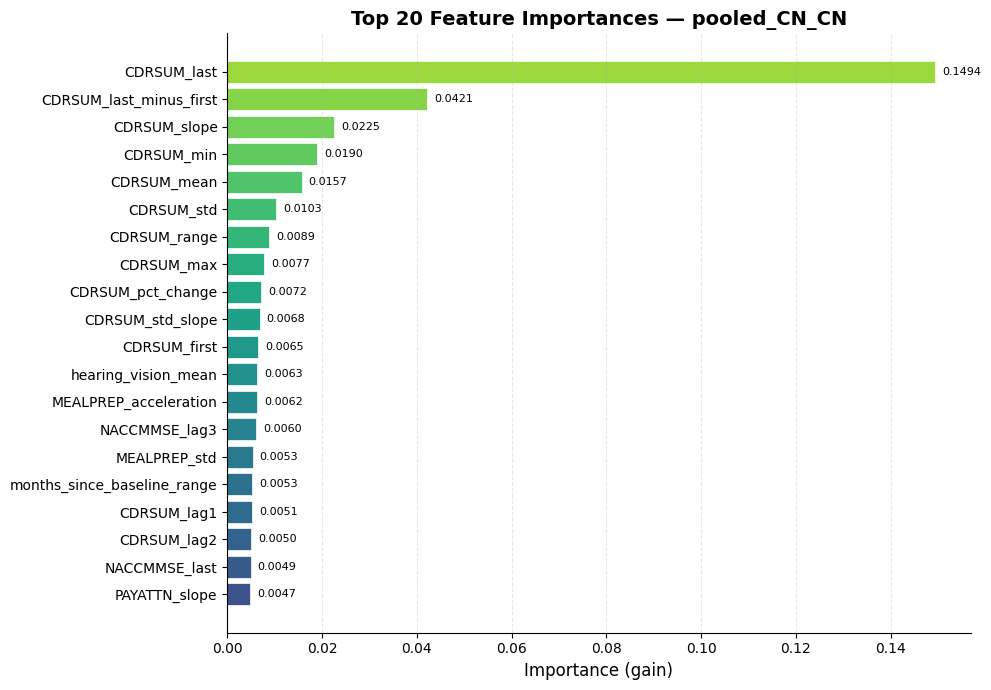

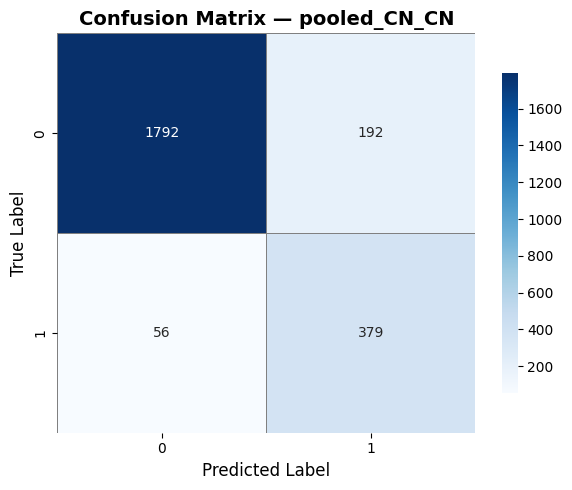

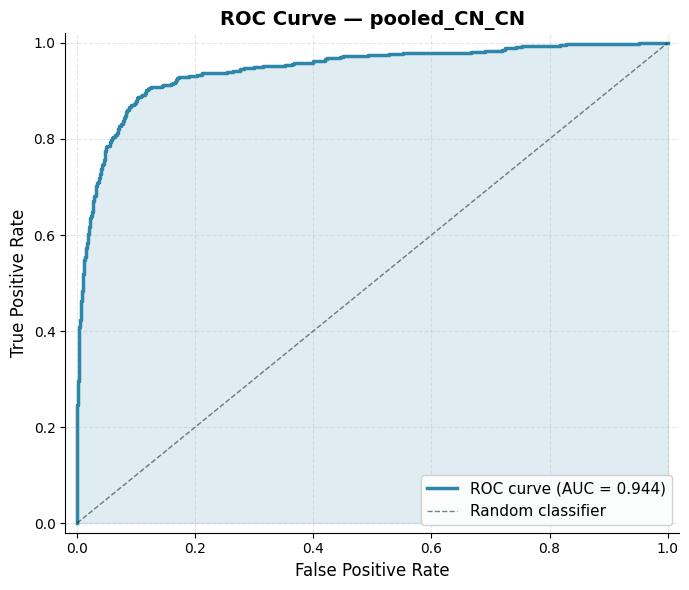


Visualizations — pooled_MCI_AD_AD


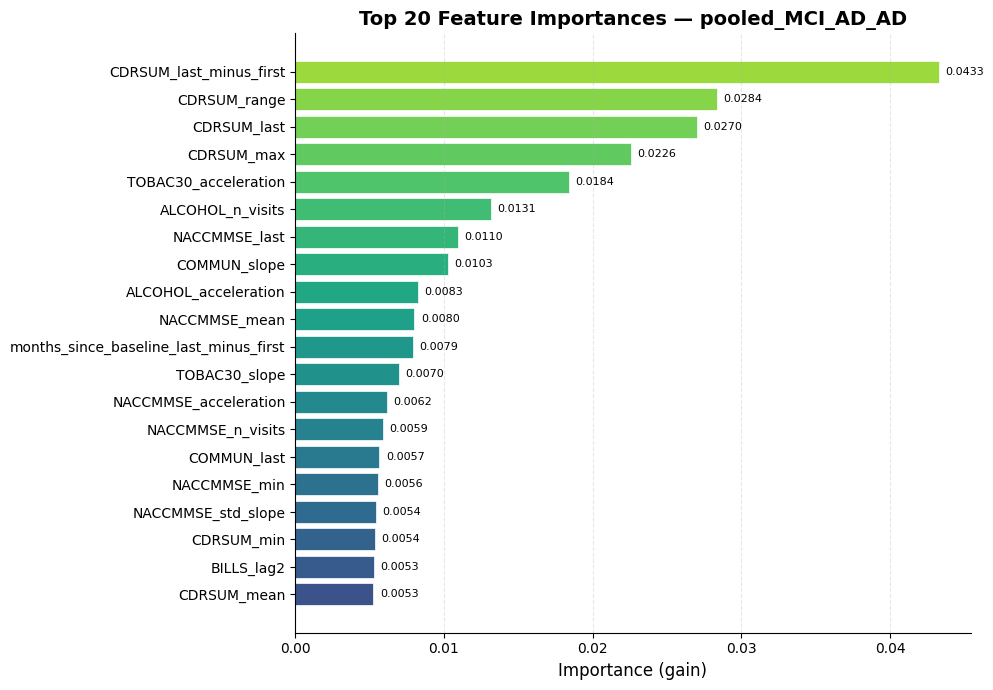

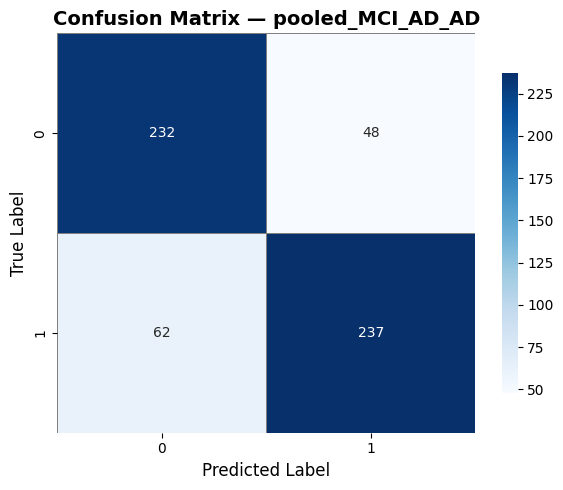

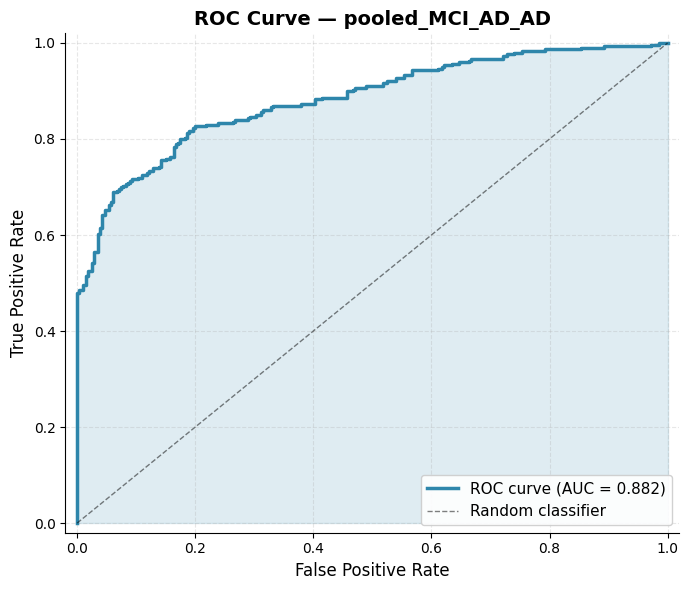

In [2]:

import importlib
import visualization as viz_module
importlib.reload(viz_module)
from visualization import plot_feature_importance, plot_confusion_mat, plot_roc
import os

charts_dir = "experiments/experiment_0.1/charts"
os.makedirs(charts_dir, exist_ok=True)

for key, (model, cols, summary) in exp0_1_models.items():
    print(f"\n{'='*60}")
    print(f"Visualizations — {key}")
    print(f"{'='*60}")

    # Feature importance
    plot_feature_importance(
        model.feature_importances_,
        cols,
        top_n=20,
        title=f"Top 20 Feature Importances — {key}",
        save_path=os.path.join(charts_dir, f"{key}_feature_importance.png"),
    )

    # Confusion matrix
    plot_confusion_mat(
        summary["y_true"],
        summary["y_pred"],
        title=f"Confusion Matrix — {key}",
        save_path=os.path.join(charts_dir, f"{key}_confusion_matrix.png"),
    )

    # ROC curve
    plot_roc(
        summary["y_true"],
        summary["y_proba"],
        title=f"ROC Curve — {key}",
        save_path=os.path.join(charts_dir, f"{key}_roc_curve.png"),
    )


- 06-03-26
- loocv with same params
- loocv results not finishing: takes too long
- cell below ran as a smoke test for making sure removing loocv didn't break any code. 

In [ ]:
import importlib
import feature_engineering as fe_module
import model as model_module
importlib.reload(fe_module)
importlib.reload(model_module)
from model import train_best_model
import os
import pandas as pd

files = [
    ("datasets/Dataset_v2/pooled_CN.csv", "CN"),
    ("datasets/Dataset_v2/pooled_MCI_AD.csv", "AD"),
]

params = {
    'n_estimators':      (100, 500),
    'max_depth':         (3, 7),
    'learning_rate':     (0.005, 0.3, 'log'),
    'subsample':         (0.4, 1.0),
    'colsample_bytree':  (0.4, 1.0),
    'colsample_bylevel': (0.5, 1.0),
    'colsample_bynode':  (0.5, 1.0),
    'min_child_weight':  (1, 10),
    'gamma':             (0.0, 5.0),
    'reg_alpha':         (1e-4, 10.0, 'log'),
    'reg_lambda':        (1e-4, 10.0, 'log'),
    'max_delta_step':    0,
}

results_dir = "experiments/experiment_0.2/grid_results"
os.makedirs(results_dir, exist_ok=True)

exp0_2_results = {}
exp0_2_models = {}    # { key: (model, cols, summary) }

for path, prog in files:
    try:
        df = pd.read_csv(path)
        base = os.path.splitext(os.path.basename(path))[0]
        csv_out = os.path.join(results_dir, f"{base}_{prog}_cv_scores.csv")
        print(f"\n{'='*60}")
        print(f"=== Optuna search: {base} ({prog}) — {len(df)} samples ===")
        print(f"{'='*60}")
        model, cols, summary = train_best_model(
            df,
            progression_type=prog,
            params=params,
            csv_path=csv_out,
            save_dir="experiments/experiment_test",
            n_jobs=10,
            n_trials=100,
            objective_metric='auc',
            model_base_name=base,
            save_artifacts=True,
        )
        key = f"{base}_{prog}"
        exp0_2_results[key] = pd.read_csv(csv_out)
        exp0_2_models[key]  = (model, cols, summary)
    except Exception as e:
        import traceback
        print(f"Error processing {path}: {e}")
        traceback.print_exc()



=== Grid search: pooled_CN (CN) — 12092 samples ===
Using StratifiedKFold with n_splits=5
Grid search: 243 hyperparameter combinations (n_jobs=10)


SKF grid search: 100%|██████████| 243/243 [04:14<00:00,  1.05s/combo]


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.90      0.94      1984
           1       0.66      0.87      0.75       435

    accuracy                           0.90      2419
   macro avg       0.82      0.89      0.84      2419
weighted avg       0.91      0.90      0.90      2419


ROC AUC Score: 0.9441
Bootstrap: valid=1000, total_attempts=1000, skipped=0 (1000/1000)

Bootstrap 95% CI (n=1000, valid_samples=1000/1000):
- Accuracy: 0.897 (CI: 0.886, 0.909) range=0.023
- Precision (macro): 0.817 (CI: 0.796, 0.836) range=0.040
- Recall (macro): 0.887 (CI: 0.871, 0.903) range=0.033
- F1 (macro): 0.844 (CI: 0.826, 0.861) range=0.035
- ROC AUC: 0.944 (CI: 0.930, 0.956) range=0.026

Saved artifacts:
- Model:   experiments/experiment_test/pooled_CN_model_CN.pkl
- Scaler:  experiments/experiment_test/pooled_CN_scaler_CN.pkl
- Imputer: experiments/experiment_test/pooled_CN_imputer_CN.pkl
- Report:  experiments/experiment_test/p

SKF grid search: 100%|██████████| 243/243 [02:27<00:00,  1.64combo/s]


Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.83      0.81       280
           1       0.83      0.79      0.81       299

    accuracy                           0.81       579
   macro avg       0.81      0.81      0.81       579
weighted avg       0.81      0.81      0.81       579


ROC AUC Score: 0.8824
Bootstrap: valid=1000, total_attempts=1000, skipped=0 (1000/1000)

Bootstrap 95% CI (n=1000, valid_samples=1000/1000):
- Accuracy: 0.810 (CI: 0.777, 0.841) range=0.064
- Precision (macro): 0.810 (CI: 0.777, 0.842) range=0.065
- Recall (macro): 0.811 (CI: 0.778, 0.843) range=0.065
- F1 (macro): 0.810 (CI: 0.776, 0.841) range=0.065
- ROC AUC: 0.882 (CI: 0.854, 0.909) range=0.055

Saved artifacts:
- Model:   experiments/experiment_test/pooled_MCI_AD_model_AD.pkl
- Scaler:  experiments/experiment_test/pooled_MCI_AD_scaler_AD.pkl
- Imputer: experiments/experiment_test/pooled_MCI_AD_imputer_AD.pkl
- Report:  experiments/exper

Using StratifiedKFold with n_splits=5
Optuna search: 5 trials, objective=auc, n_jobs=4


Optuna trials: 100%|██████████| 5/5 [00:01<00:00,  2.61trial/s]


Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.84      0.81       279
           1       0.83      0.78      0.81       288

    accuracy                           0.81       567
   macro avg       0.81      0.81      0.81       567
weighted avg       0.81      0.81      0.81       567


ROC AUC Score: 0.9013
PR-AUC (Average Precision): 0.9188
Bootstrap: valid=1000, total_attempts=1000, skipped=0 (1000/1000)

Bootstrap 95% CI (n=1000, valid_samples=1000/1000):
- Accuracy: 0.808 (CI: 0.774, 0.838) range=0.064
- Precision (macro): 0.809 (CI: 0.776, 0.840) range=0.064
- Recall (macro): 0.808 (CI: 0.775, 0.838) range=0.063
- F1 (macro): 0.808 (CI: 0.774, 0.838) range=0.064
- ROC AUC: 0.901 (CI: 0.875, 0.925) range=0.050
- PPV: 0.830 (CI: 0.786, 0.875) range=0.089
- NPV: 0.787 (CI: 0.740, 0.831) range=0.091


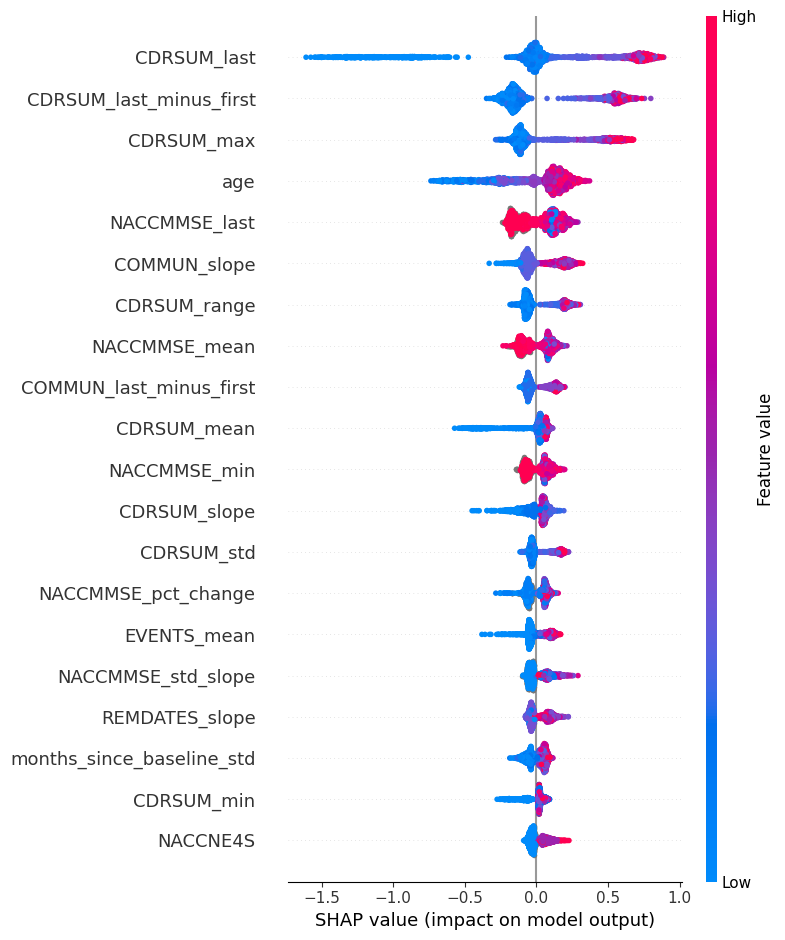

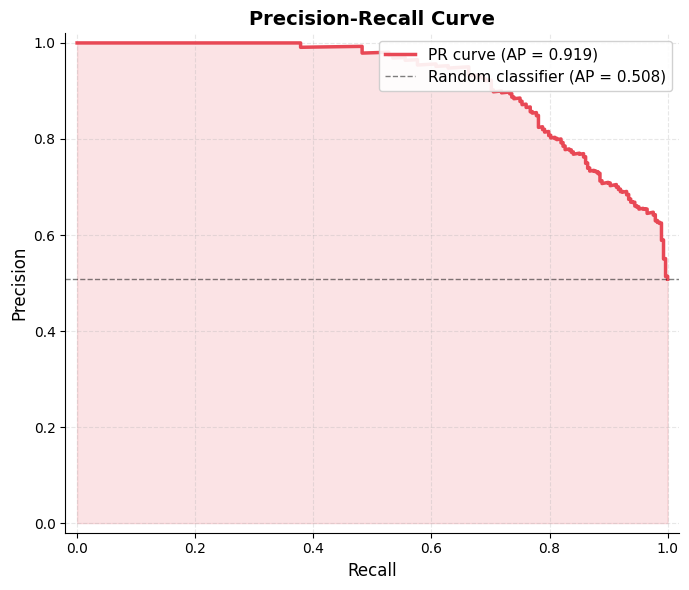


Saved artifacts:
- Model:   experiments/experiment_verify/verify_model_AD.pkl
- Scaler:  experiments/experiment_verify/verify_scaler_AD.pkl
- Imputer: experiments/experiment_verify/verify_imputer_AD.pkl
- Report:  experiments/experiment_verify/verify_report_AD.txt
Using StratifiedKFold with n_splits=5
Optuna search: 3 trials, objective=avg_precision, n_jobs=4


Optuna trials: 100%|██████████| 3/3 [00:00<00:00,  3.50trial/s]


Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.83      0.81       279
           1       0.83      0.79      0.81       288

    accuracy                           0.81       567
   macro avg       0.81      0.81      0.81       567
weighted avg       0.81      0.81      0.81       567


ROC AUC Score: 0.9058
PR-AUC (Average Precision): 0.9196
Bootstrap: valid=1000, total_attempts=1000, skipped=0 (1000/1000)

Bootstrap 95% CI (n=1000, valid_samples=1000/1000):
- Accuracy: 0.808 (CI: 0.774, 0.841) range=0.067
- Precision (macro): 0.808 (CI: 0.775, 0.841) range=0.066
- Recall (macro): 0.808 (CI: 0.775, 0.841) range=0.067
- F1 (macro): 0.808 (CI: 0.774, 0.841) range=0.067
- ROC AUC: 0.906 (CI: 0.881, 0.928) range=0.047
- PPV: 0.825 (CI: 0.780, 0.871) range=0.091
- NPV: 0.791 (CI: 0.746, 0.837) range=0.091


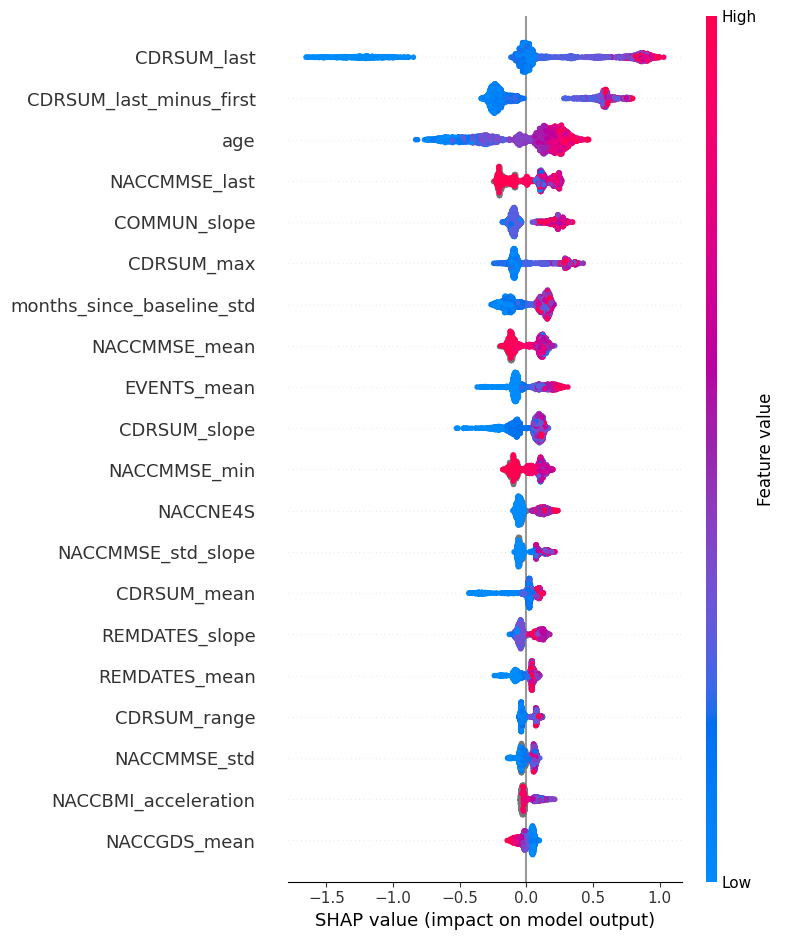

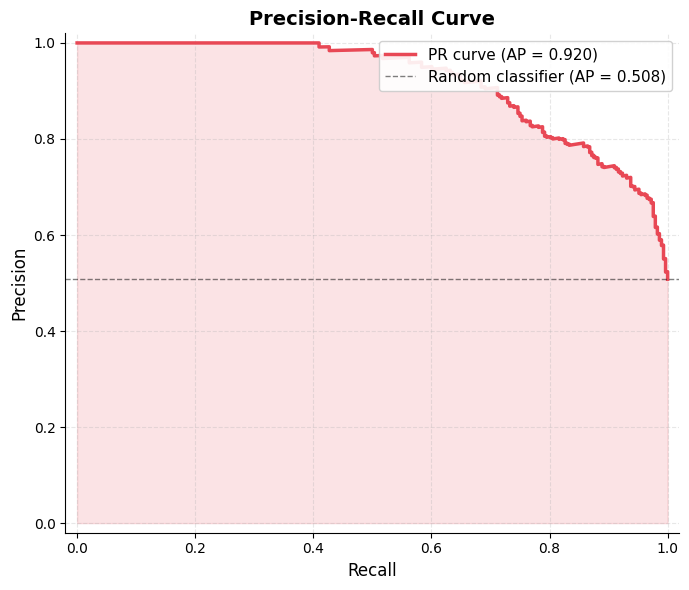


VERIFICATION RESULTS  ✓ 6 passed  ✗ 0 failed
  ✓  PPV + NPV keys in bootstrap_metrics
  ✓  PPV + NPV CI bounds are valid
  ✓  CV CSV has 'trial' column with 5 rows
  ✓  shap_values in summary, shape=(2266, 312)
  ✓  base_avg_precision = 0.9188
  ✓  objective_metric='avg_precision' path completed without error


In [ ]:
# ── Verification Cell ────────────────────────────────────────────────────────
# Runs a smoke test with n_trials=5 to validate the full pipeline end-to-end.
# Checks: Optuna search, NPV/PPV keys, CSV trial column, SHAP values in summary.

import importlib
import feature_engineering as fe_module
import model as model_module
import visualization as viz_module
importlib.reload(fe_module)
importlib.reload(model_module)
importlib.reload(viz_module)
from model import train_best_model
import os, pandas as pd

VERIFY_PATH  = "datasets/Dataset_v2_1/pooled_MCI_AD.csv"
VERIFY_PROG  = "AD"
VERIFY_DIR   = "experiments/experiment_verify"
VERIFY_CSV   = os.path.join(VERIFY_DIR, "verify_cv_scores.csv")

params_smoke = {
    'n_estimators':      (50, 150),
    'max_depth':         (3, 5),
    'learning_rate':     (0.01, 0.2, 'log'),
    'subsample':         (0.6, 1.0),
    'colsample_bytree':  (0.6, 1.0),
    'colsample_bylevel': (0.5, 1.0),
    'colsample_bynode':  (0.5, 1.0),
    'min_child_weight':  (1, 5),
    'gamma':             (0.0, 2.0),
    'reg_alpha':         (1e-4, 1.0, 'log'),
    'reg_lambda':        (1e-4, 1.0, 'log'),
    'max_delta_step':    0,
}

passed = []
failed = []

try:
    df_v = pd.read_csv(VERIFY_PATH)
    model_v, cols_v, summary_v = train_best_model(
        df_v,
        progression_type=VERIFY_PROG,
        params=params_smoke,
        csv_path=VERIFY_CSV,
        save_dir=VERIFY_DIR,
        n_jobs=4,
        n_trials=5,
        objective_metric='auc',
        model_base_name="verify",
        save_artifacts=True,
    )

    # 1. NPV / PPV present in bootstrap metrics
    bm = summary_v['bootstrap_metrics']
    assert 'ppv' in bm and 'npv' in bm, "FAIL: ppv/npv missing from bootstrap_metrics"
    passed.append("PPV + NPV keys in bootstrap_metrics")

    # 2. CI tuples well-formed
    for metric_key in ('ppv', 'npv'):
        pt, (lo, hi) = bm[metric_key]
        assert 0.0 <= pt <= 1.0, f"FAIL: {metric_key} point estimate out of range"
        assert lo <= pt <= hi,   f"FAIL: {metric_key} CI bounds inconsistent"
    passed.append("PPV + NPV CI bounds are valid")

    # 3. CV scores CSV has a 'trial' column
    cv_df = pd.read_csv(VERIFY_CSV)
    assert 'trial' in cv_df.columns, "FAIL: 'trial' column missing from CV CSV"
    assert len(cv_df) == 5, f"FAIL: expected 5 trial rows, got {len(cv_df)}"
    passed.append(f"CV CSV has 'trial' column with {len(cv_df)} rows")

    # 4. SHAP values + X_train in summary
    import numpy as np
    assert 'shap_values' in summary_v, "FAIL: shap_values missing from summary"
    assert 'X_train' in summary_v,     "FAIL: X_train missing from summary"
    X_shape = summary_v['shap_values'].shape
    assert X_shape[1] == len(cols_v),  "FAIL: SHAP value columns don't match feature count"
    assert summary_v['X_train'].shape == X_shape, "FAIL: X_train shape doesn't match shap_values shape"
    passed.append(f"shap_values + X_train in summary, shape={X_shape}")

    # 5. PR-AUC key in summary
    assert 'base_avg_precision' in summary_v, "FAIL: base_avg_precision missing from summary"
    passed.append(f"base_avg_precision = {summary_v['base_avg_precision']:.4f}")

    # 6. objective_metric='avg_precision' path
    model_ap, _, summary_ap = train_best_model(
        df_v,
        progression_type=VERIFY_PROG,
        params={k: (v[0], v[1]) if isinstance(v, tuple) and len(v) == 3 else v for k, v in params_smoke.items()},
        csv_path=VERIFY_CSV.replace(".csv", "_ap.csv"),
        save_dir=VERIFY_DIR,
        n_jobs=4,
        n_trials=3,
        objective_metric='avg_precision',
        model_base_name="verify_ap",
        save_artifacts=False,
    )
    passed.append("objective_metric='avg_precision' path completed without error")

except AssertionError as e:
    failed.append(str(e))
except Exception as e:
    import traceback
    failed.append(f"Unexpected error: {e}")
    traceback.print_exc()

print("\n" + "="*60)
print(f"VERIFICATION RESULTS  ✓ {len(passed)} passed  ✗ {len(failed)} failed")
print("="*60)
for msg in passed:
    print(f"  ✓  {msg}")
for msg in failed:
    print(f"  ✗  {msg}")



=== Optuna search: pooled_CN (CN) — 12092 samples ===
Using StratifiedKFold with n_splits=5
Optuna search: 100 trials, objective=auc, n_jobs=8


Optuna trials: 100%|██████████| 100/100 [01:02<00:00,  1.61trial/s]


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.90      0.93      1984
           1       0.66      0.88      0.75       435

    accuracy                           0.90      2419
   macro avg       0.82      0.89      0.84      2419
weighted avg       0.92      0.90      0.90      2419


ROC AUC Score: 0.9431
PR-AUC (Average Precision): 0.8494
Bootstrap: valid=1000, total_attempts=1000, skipped=0 (1000/1000)

Bootstrap 95% CI (n=1000, valid_samples=1000/1000):
- Accuracy: 0.897 (CI: 0.885, 0.909) range=0.023
- Precision (macro): 0.816 (CI: 0.797, 0.835) range=0.039
- Recall (macro): 0.889 (CI: 0.871, 0.905) range=0.034
- F1 (macro): 0.844 (CI: 0.827, 0.862) range=0.034
- ROC AUC: 0.943 (CI: 0.929, 0.955) range=0.026
- PPV: 0.661 (CI: 0.623, 0.700) range=0.077
- NPV: 0.971 (CI: 0.962, 0.978) range=0.015


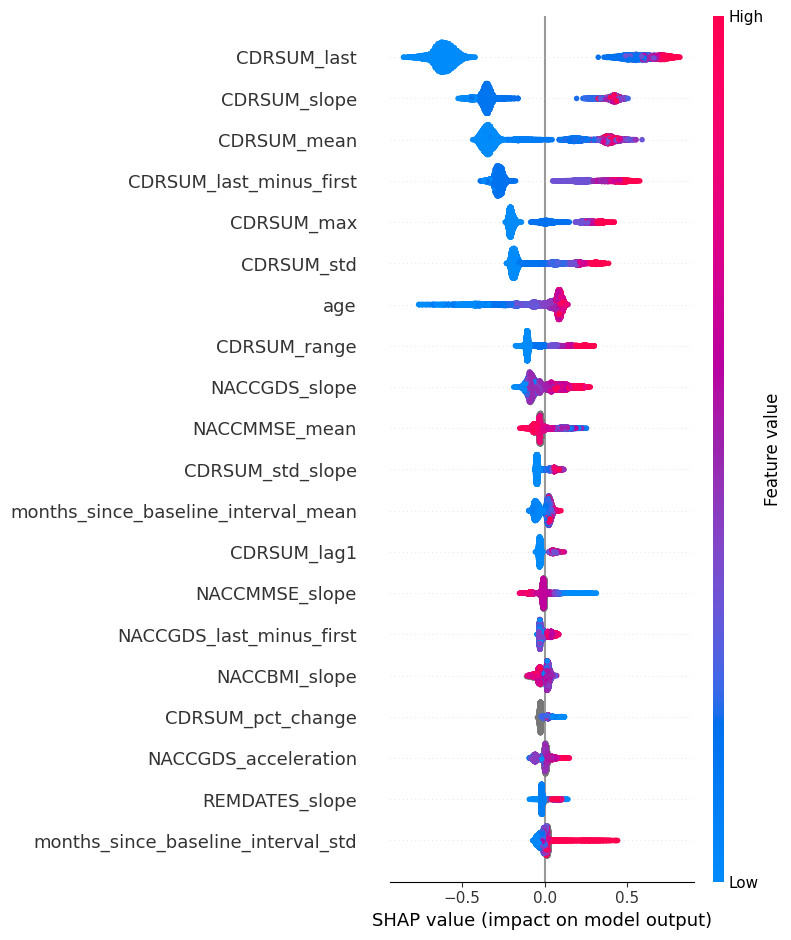

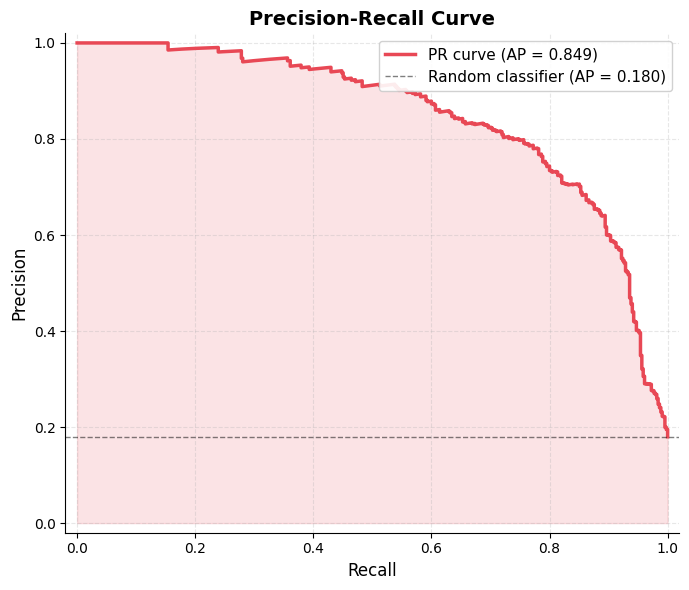


Saved artifacts:
- Model:   experiments/experiment_bayesian/pooled_CN_model_CN.pkl
- Scaler:  experiments/experiment_bayesian/pooled_CN_scaler_CN.pkl
- Imputer: experiments/experiment_bayesian/pooled_CN_imputer_CN.pkl
- Report:  experiments/experiment_bayesian/pooled_CN_report_CN.txt

=== Optuna search: pooled_MCI_AD (AD) — 2891 samples ===
Using StratifiedKFold with n_splits=5
Optuna search: 100 trials, objective=auc, n_jobs=8


Optuna trials: 100%|██████████| 100/100 [00:27<00:00,  3.68trial/s]


Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.81      0.79       280
           1       0.82      0.77      0.79       299

    accuracy                           0.79       579
   macro avg       0.79      0.79      0.79       579
weighted avg       0.79      0.79      0.79       579


ROC AUC Score: 0.8780
PR-AUC (Average Precision): 0.9048
Bootstrap: valid=1000, total_attempts=1000, skipped=0 (1000/1000)

Bootstrap 95% CI (n=1000, valid_samples=1000/1000):
- Accuracy: 0.791 (CI: 0.758, 0.824) range=0.066
- Precision (macro): 0.792 (CI: 0.758, 0.824) range=0.066
- Recall (macro): 0.792 (CI: 0.758, 0.825) range=0.067
- F1 (macro): 0.791 (CI: 0.757, 0.824) range=0.066
- ROC AUC: 0.878 (CI: 0.849, 0.904) range=0.055
- PPV: 0.816 (CI: 0.771, 0.861) range=0.091
- NPV: 0.768 (CI: 0.719, 0.816) range=0.097


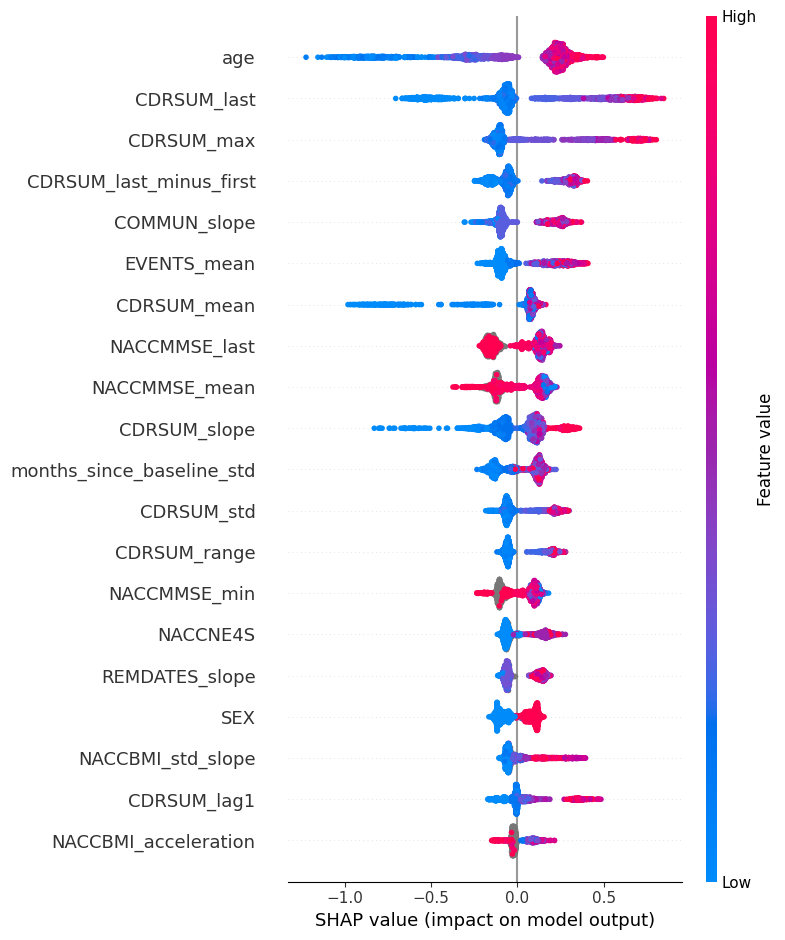

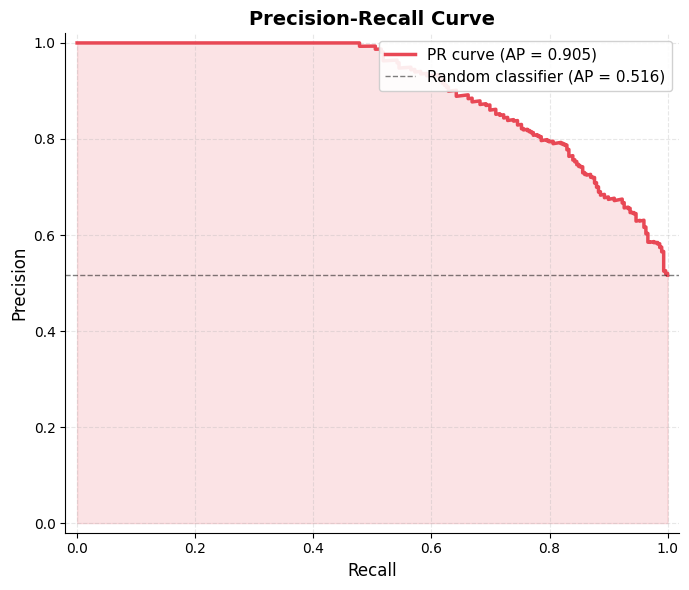


Saved artifacts:
- Model:   experiments/experiment_bayesian/pooled_MCI_AD_model_AD.pkl
- Scaler:  experiments/experiment_bayesian/pooled_MCI_AD_scaler_AD.pkl
- Imputer: experiments/experiment_bayesian/pooled_MCI_AD_imputer_AD.pkl
- Report:  experiments/experiment_bayesian/pooled_MCI_AD_report_AD.txt

Visualizations — pooled_CN_CN


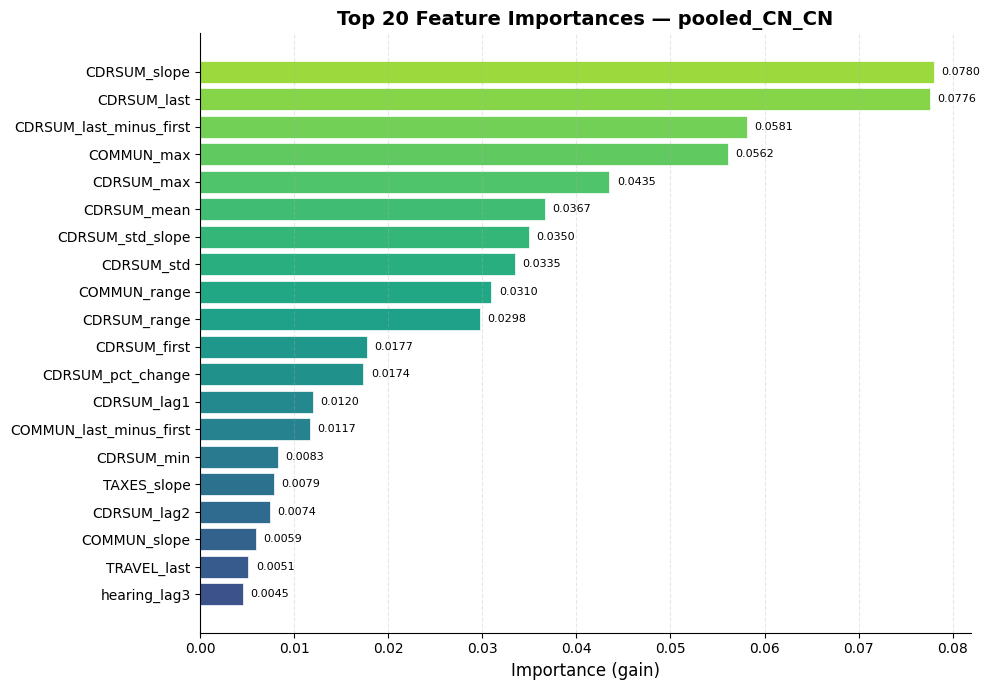

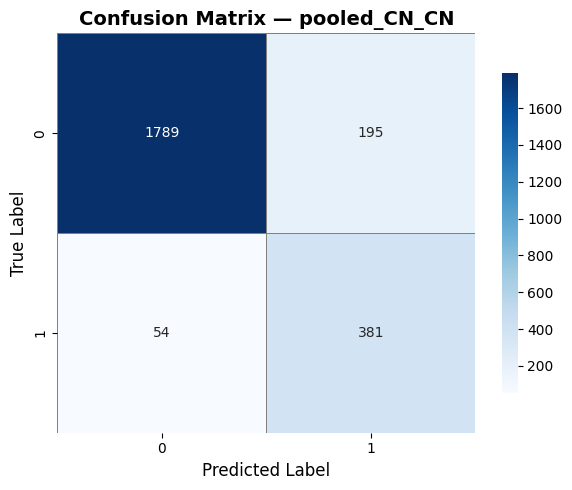

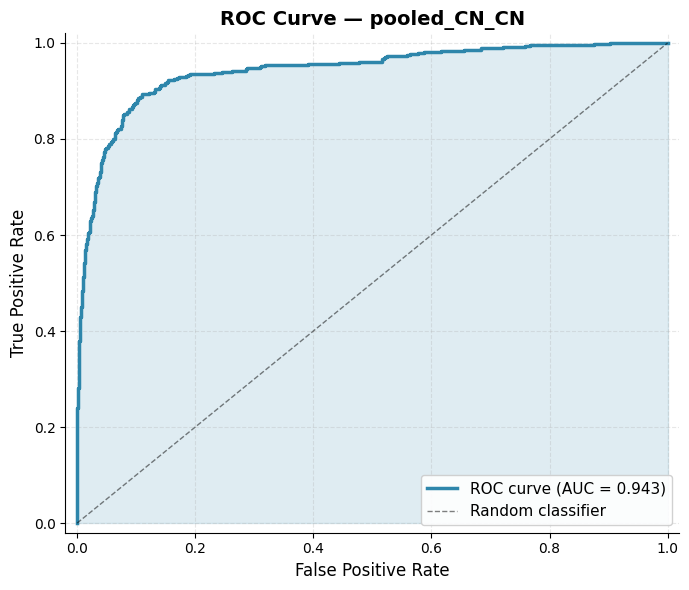

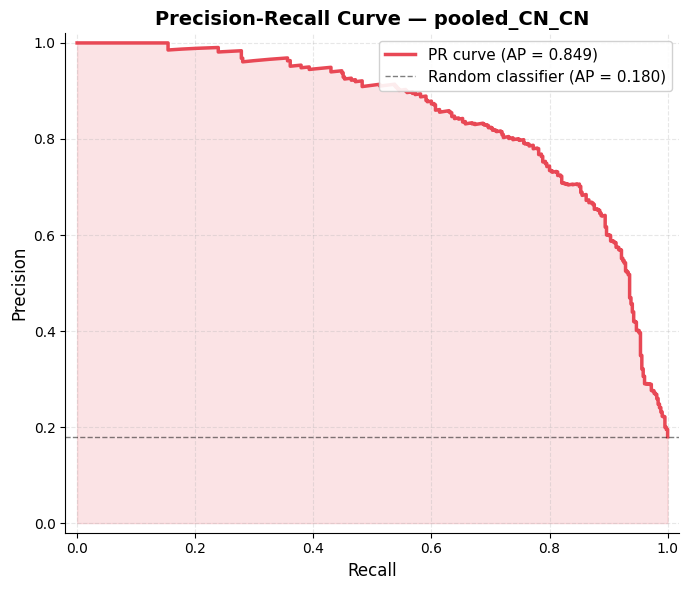

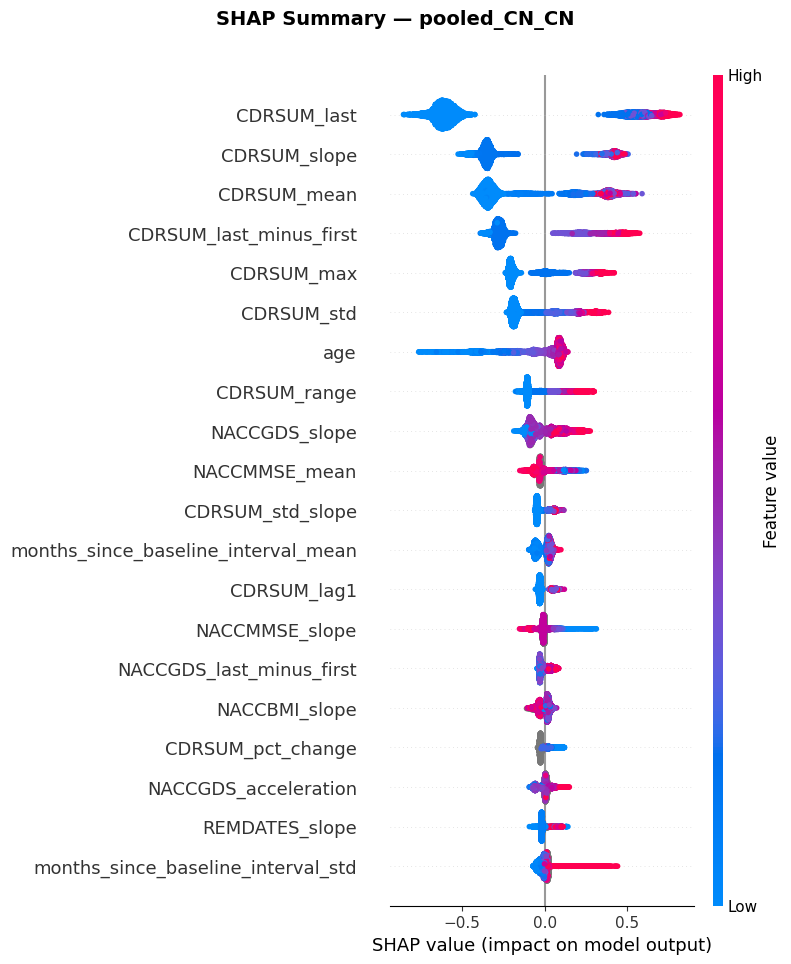


Visualizations — pooled_MCI_AD_AD


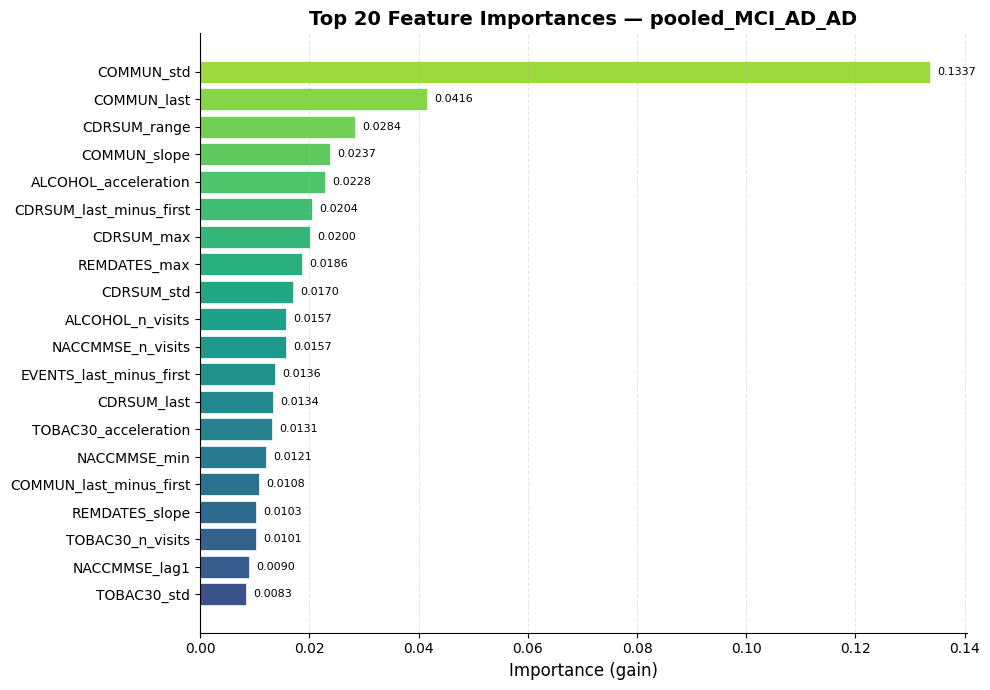

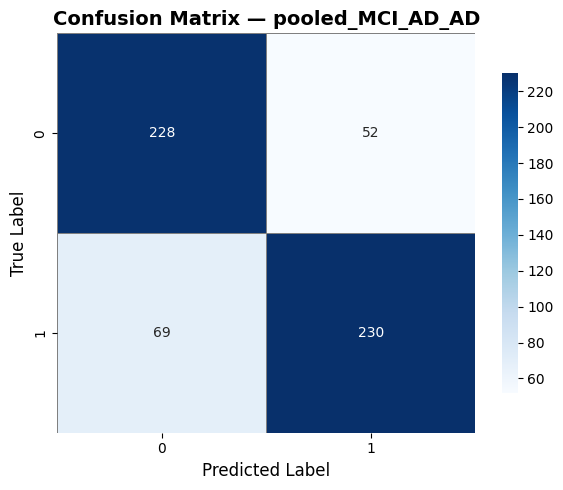

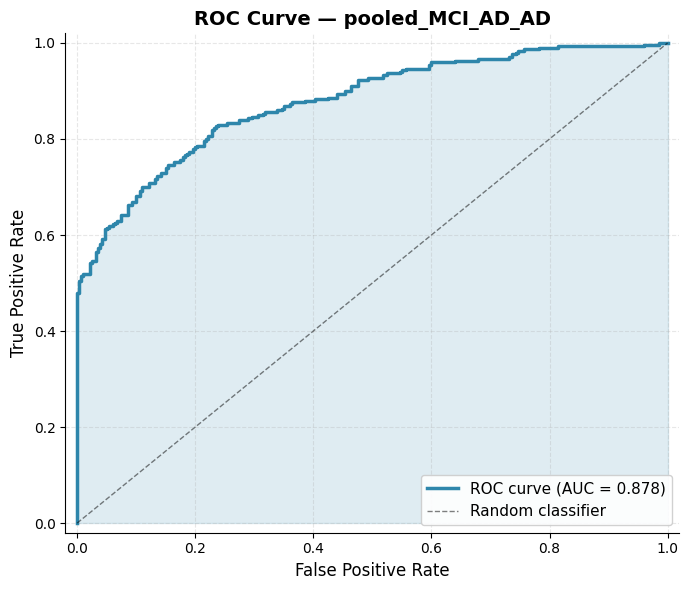

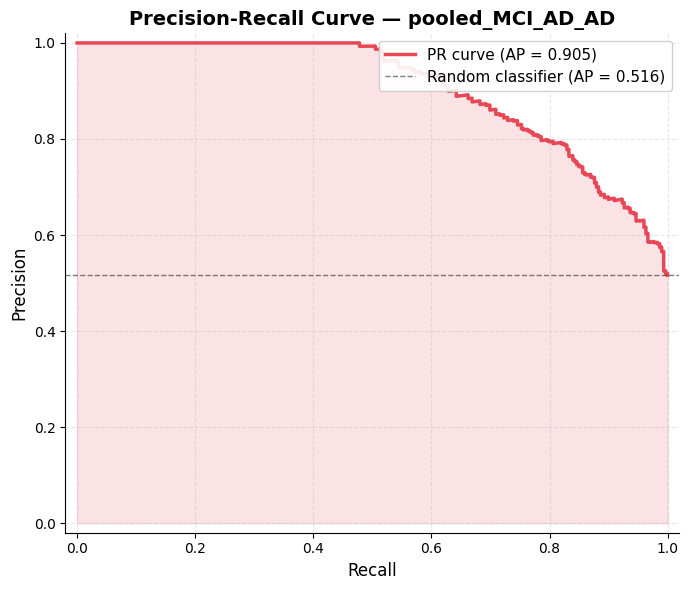

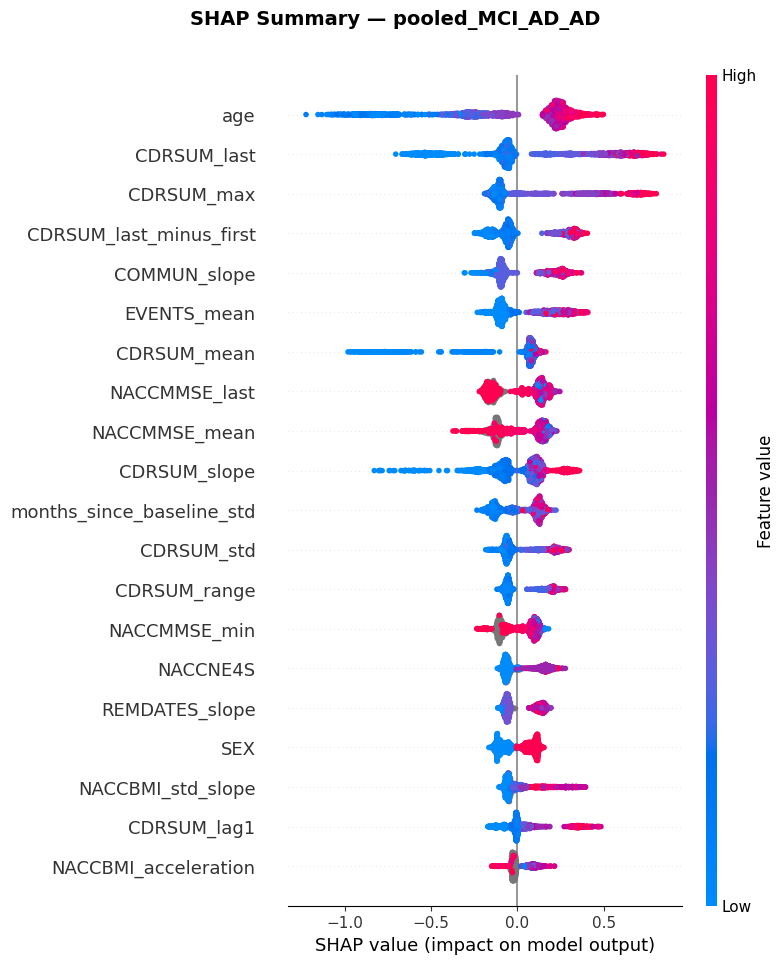

In [ ]:
import importlib
import feature_engineering as fe_module
import model as model_module
import visualization as viz_module
importlib.reload(fe_module)
importlib.reload(model_module)
importlib.reload(viz_module)
from model import train_best_model
from visualization import plot_feature_importance, plot_confusion_mat, plot_roc, plot_pr_curve, plot_shap_summary
import os
import pandas as pd

files = [
    ("datasets/Dataset_v2/pooled_CN.csv", "CN"),
    ("datasets/Dataset_v2/pooled_MCI_AD.csv", "AD"),
]

# params dict: scalar = fixed value, (lo, hi) = int range, (lo, hi, 'log') = log-scale float range
params = {
    'n_estimators':      (100, 1000),
    'max_depth':         (3, 10),
    'learning_rate':     (0.005, 0.3, 'log'),
    'subsample':         (0.2, 1.0),
    'colsample_bytree':  (0.2, 1.0),
    'colsample_bylevel': (0.2, 1.0),
    'colsample_bynode':  (0.2, 1.0),
    'min_child_weight':  (1, 10),
    'gamma':             (0.0, 5.0),
    'reg_alpha':         (1e-4, 10.0, 'log'),
    'reg_lambda':        (1e-4, 10.0, 'log'),
    'max_delta_step':    0,
}

EXPERIMENT  = "experiment_bayesian"
results_dir = f"experiments/{EXPERIMENT}/grid_results"
charts_dir  = f"experiments/{EXPERIMENT}/charts"
os.makedirs(results_dir, exist_ok=True)
os.makedirs(charts_dir,  exist_ok=True)

exp_bayesian_results = {}
exp_bayesian_models  = {}    # { key: (model, cols, summary) }

# ── Training ──────────────────────────────────────────────────────────────────
for path, prog in files:
    try:
        df = pd.read_csv(path)
        base = os.path.splitext(os.path.basename(path))[0]
        csv_out = os.path.join(results_dir, f"{base}_{prog}_cv_scores.csv")
        print(f"\n{'='*60}")
        print(f"=== Optuna search: {base} ({prog}) — {len(df)} samples ===")
        print(f"{'='*60}")
        model, cols, summary = train_best_model(
            df,
            progression_type=prog,
            params=params,
            csv_path=csv_out,
            save_dir=f"experiments/{EXPERIMENT}",
            n_jobs=10,
            n_trials=1000,
            objective_metric='auc',
            model_base_name=base,
            save_artifacts=True,
        )
        key = f"{base}_{prog}"
        exp_bayesian_results[key] = pd.read_csv(csv_out)
        exp_bayesian_models[key]  = (model, cols, summary)
    except Exception as e:
        import traceback
        print(f"Error processing {path}: {e}")
        traceback.print_exc()

# ── Visualizations ────────────────────────────────────────────────────────────
for key, (model, cols, summary) in exp_bayesian_models.items():
    print(f"\n{'='*60}")
    print(f"Visualizations — {key}")
    print(f"{'='*60}")

    # Feature importance
    plot_feature_importance(
        model.feature_importances_,
        cols,
        top_n=20,
        title=f"Top 20 Feature Importances — {key}",
        save_path=os.path.join(charts_dir, f"{key}_feature_importance.png"),
    )

    # Confusion matrix
    plot_confusion_mat(
        summary["y_true"],
        summary["y_pred"],
        title=f"Confusion Matrix — {key}",
        save_path=os.path.join(charts_dir, f"{key}_confusion_matrix.png"),
    )

    # ROC curve
    plot_roc(
        summary["y_true"],
        summary["y_proba"],
        title=f"ROC Curve — {key}",
        save_path=os.path.join(charts_dir, f"{key}_roc_curve.png"),
    )

    # Precision-Recall curve
    plot_pr_curve(
        summary["y_true"],
        summary["y_proba"],
        title=f"Precision-Recall Curve — {key}",
        save_path=os.path.join(charts_dir, f"{key}_pr_curve.png"),
    )

    # SHAP beeswarm (uses stored X_train — no recomputation needed)
    plot_shap_summary(
        model,
        summary["X_train"],
        cols,
        title=f"SHAP Summary — {key}",
        save_path=os.path.join(charts_dir, f"{key}_shap_summary.png"),
    )
